In [2]:
from fleet_replacement.episode import EpisodeRecord, EpisodeRecorder
from fleet_replacement.envs.fleet_replacement import FleetReplacementEnv
from fleet_replacement.policies import LookaheadAgent
from fleet_replacement.config import load_env_config

config = load_env_config("../configs/env.yaml")
env = EpisodeRecorder(FleetReplacementEnv(config=config))
agent = LookaheadAgent(config)

obs, _ = env.reset(seed=42)
while True:
    obs, reward, terminated, truncated, info = env.step(agent.select_action(obs))
    if terminated or truncated:
        break

record = env.episode_record
df = record.to_dataframe()  # pandas DataFrame, indexed by year
record.save("../results/ep42.pkl")  # persist

# For visualisation:
record.years  # (35,)
record.n_electric  # (35,)
record.actions  # (35, 10)  — heatmap of decisions per slot
record.reward_component("revenue")  # (35,)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\comm

array([39000000.        , 39000000.        , 39000000.        ,
       39000000.        , 39000000.        , 39000000.        ,
       39000000.        , 39000000.        , 39000000.        ,
       39000000.        , 39000000.        , 39000000.        ,
       39000000.        , 39000000.        , 39000000.        ,
       29556883.36088458, 30118242.34940621, 30754851.01429849,
       31449185.46108633, 32175000.        , 32900814.53891367,
       33595148.98570151, 34231757.65059379, 34793116.63911543,
       35271351.14288802, 35666952.11722025, 35986305.99334277,
       36239066.20918426, 36436009.77844428, 36587597.73651873,
       36703180.90459179, 36790679.31262556, 36856557.01909275,
       36905953.19099058, 36942877.30935171])

In [3]:
df.head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2025,0,10,0.0,18.000000,3.000000,1600000.0,3200000.00,0.700000,17151060.0,39000000.0,1.426494e+07,0.0,4000000.0,384000.0,3200000.0,0.0,3584000.0,1.826494e+07,17151060.0
2026,0,10,1.0,18.288383,2.875461,1600000.0,2955045.00,0.700834,16737028.0,39000000.0,1.467897e+07,0.0,4000000.0,384000.0,3200000.0,0.0,3584000.0,1.867897e+07,16737028.0
2027,0,10,2.0,18.819195,2.657462,1600000.0,2553818.25,0.701124,16554516.0,39000000.0,1.486148e+07,0.0,4000000.0,384000.0,3200000.0,0.0,3584000.0,1.886148e+07,16554516.0
2028,0,10,3.0,19.053183,2.621959,1600000.0,2361374.50,0.701515,16662034.0,39000000.0,1.475397e+07,0.0,4000000.0,384000.0,3200000.0,0.0,3584000.0,1.875397e+07,16662034.0
2029,0,10,4.0,18.915342,2.713659,1600000.0,2286878.75,0.702041,16497044.0,39000000.0,1.491896e+07,0.0,4000000.0,384000.0,3200000.0,0.0,3584000.0,1.891896e+07,16497044.0


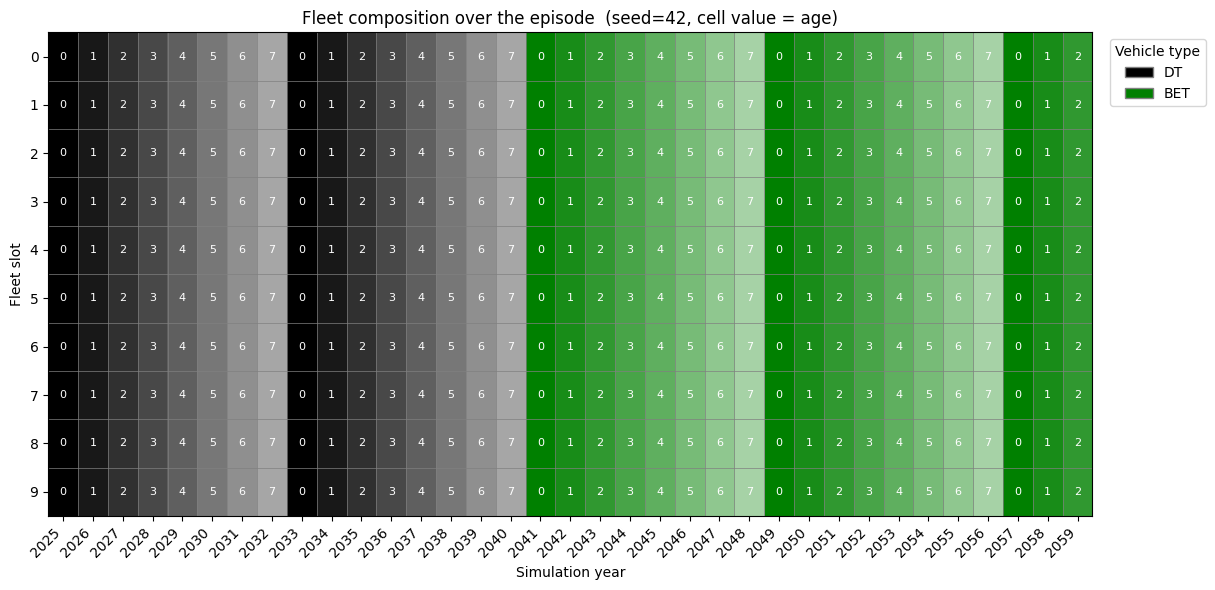

In [7]:
from plot_helpers import plot_episode_fleet_composition

plot_episode_fleet_composition(record)